# Create the emissivity table

Here, I describe how I create the emissivity cube used for emission weighting. Beforehand, I need to create a table of flux from which I'll be interpolating. This table is created by using `xspec`, with the following code : 

```python
import xspec as xs
import numpy as np
from multiprocessing import Pool

xs.Xset.chatter = 0

xs.Xset.allowPrompting = False

def getcountsTZ(TZ_vec,
	nH = 0.03, #10^22 cm-2
	z  = 0.1,  #Cluster redshift
	norm = 1,  #For normalisation
	v = 0.,   #Velocity broadening
	):
	
	T, Z = TZ_vec

	xs.AllData.clear()
	#Load instrument responses
	fs1 = xs.FakeitSettings(response = "/xifu/home/mola/XIFU_Sims_Turbulence_NewConfig/RMF.rmf", 
	                        arf = '/xifu/home/mola/XIFU_Sims_Turbulence_NewConfig/ARF.arf',
	                        exposure=1.0)

	#Define models
	m = xs.Model('phabs*bapec')

	#Define parameters
	m.setPars(nH, T, Z, z, v, norm)

	#Fakeit
	xs.AllData.fakeit(1, fs1, noWrite = True)

	#Folded flux
	flux = np.sum(np.array(m.folded(1))) #ph/s
	#This is the sum of the number of expected number photons received on the detector for the given one second exposure

	return flux 


if __name__ == '__main__' :

	Npts = 100
	T_list = np.linspace(0.1, 10, Npts)
	Z_list = np.linspace(0.01, 1, Npts)
	mesh = np.meshgrid(T_list, Z_list)
	TZ = np.vstack((mesh[0].flatten(), mesh[1].flatten())).T
	
	p = Pool(32)
	flux_table = p.map(getcountsTZ, TZ)
	print(flux_table)

	np.save('flux_table_APEC_newXIFU.npy', flux_table)
```


Once I have this table, I use it with the emissivity code to produce an emissivity cube.

First, let's do the imports

In [1]:
# Classics
import matplotlib.pyplot as plt
import jax.numpy as jnp
import cmasher as cmr

# Astropy
import astropy.units as units
from astropy.cosmology import LambdaCDM
cosmo = LambdaCDM(H0 = 70, Om0 = 0.3, Ode0 = 0.7)

from fast_turbulence_sim.grid import SpatialGrid3D
from fast_turbulence_sim.emissivity import XrayEmissivity

Define the spatial grid

In [2]:
# Pixel size 
pixsize_m = 317e-6 # 317 um
focal_length = 12 # 12 m
pixsize_arcmin = pixsize_m/focal_length * 180 / jnp.pi * 60
pixsize_kpc = pixsize_arcmin * cosmo.kpc_proper_per_arcmin(0.1).value

# Spatial grid
spatial_grid = SpatialGrid3D(pixsize=pixsize_kpc, 
                             shape=(232,232), 
                             los_factor=5)
print('The pixel size in kiloparsecs is {:.2f} kpc'.format(pixsize_kpc))



The pixel size in kiloparsecs is 10.05 kpc


Initialize the emissivty cube function with haiku

In [6]:
# Path to grid
path_to_TZ_grid = '../../data/TZ_table/flux_table_APEC_newXIFU.npy'

# Exposure
exposure = 125e3 

# Redshift to cluster
z = 0.1

# Pixel size in centimeters, projected at redshift of cluster
pixsize_cm = pixsize_kpc * units.kiloparsec.to(units.cm)

# Filling factor
pixel_pitch = 317
absorber_size = 310.7
filling_factor = (absorber_size/pixel_pitch)**2

em_func = XrayEmissivity(TZ_grid_to_interp_from = path_to_TZ_grid,
                         R500 = 1309.,
                         M500 = 0.7,
                         z = z)

Create the cube (long step, as the cube is rather large)

In [7]:
em_cube = em_func(spatial_grid.R,
                exposure = 125e3,
                pixsize_cm = pixsize_cm,
                filling_factor= (310.7/317)**2)

Show the output map of expected counts, which is the sum of the emissivity along the line of sight : 

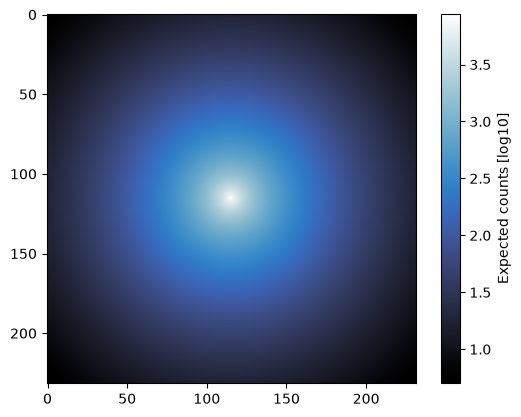

In [8]:
plt.imshow(jnp.log10(jnp.sum(em_cube, axis= -1)), cmr.arctic)
plt.colorbar(label = 'Expected counts [log10]')

<div class="admonition warning">
    <p class="admonition-title">Warning</p>
    <p>
        This map does not take into account the PSF and vignetting ! 
        So any comparison with the actual count map has to take that 
        into account as well as a Poisson realization.
    </p>
</div>